In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout
import matplotlib.pyplot as plt
import numpy as np
import time

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training Images:", x_train.shape)
print("Testing Images :", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: (60000, 28, 28)
Testing Images : (10000, 28, 28)


In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
x_train_ann = x_train.reshape(-1, 28 * 28)
x_test_ann = x_test.reshape(-1, 28 * 28)

In [ ]:
x_train_cnn = x_train.reshape(-1,28,28,1)
x_test_cnn = x_test.reshape(-1,28,28,1)

In [ ]:
ann_model = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start = time.time()

history_ann = ann_model.fit(
    x_train_ann,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1
)

ann_time = time.time() - start

print("ANN Training Time:", round(ann_time,2), "seconds")

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8557 - loss: 0.4608 - val_accuracy: 0.9557 - val_loss: 0.1506
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9419 - loss: 0.1875 - val_accuracy: 0.9644 - val_loss: 0.1168
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9576 - loss: 0.1397 - val_accuracy: 0.9694 - val_loss: 0.0993
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9642 - loss: 0.1177 - val_accuracy: 0.9734 - val_loss: 0.0886
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9692 - loss: 0.0997 - val_accuracy: 0.9740 - val_loss: 0.0875
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9737 - loss: 0.0833 - val_accuracy: 0.9758 - val_loss: 0.0900
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9745 - loss: 0.0787 - val_accuracy: 0.9769 - val_loss: 0.0829
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9780 - loss: 0.0697 - val_accuracy: 0.

In [ ]:
ann_loss, ann_acc = ann_model.evaluate(
    x_test_ann,
    y_test,
    verbose=0
)

print("ANN Accuracy:", ann_acc)

ANN Accuracy: 0.9793999791145325


In [ ]:
cnn_model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128,activation='relu'),

    Dropout(0.5),

    Dense(10,activation='softmax')

])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start = time.time()

history_cnn = cnn_model.fit(
    x_train_cnn,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1
)

cnn_time = time.time() - start

print("CNN Training Time:", round(cnn_time,2), "seconds")

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.8872 - loss: 0.3598 - val_accuracy: 0.9751 - val_loss: 0.0803
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 55ms/step - accuracy: 0.9654 - loss: 0.1159 - val_accuracy: 0.9839 - val_loss: 0.0534
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.9750 - loss: 0.0861 - val_accuracy: 0.9848 - val_loss: 0.0498
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.9790 - loss: 0.0687 - val_accuracy: 0.9887 - val_loss: 0.0398
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.9820 - loss: 0.0585 - val_accuracy: 0.9897 - val_loss: 0.0371
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.9851 - loss: 0.0492 - val_accuracy: 0.9892 - val_loss: 0.0350
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.9865 - loss: 0.0448 - val_accuracy: 0.9903 - val_loss: 0.0352
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.9877 - loss: 0.0389 - 

In [ ]:
cnn_loss, cnn_acc = cnn_model.evaluate(
    x_test_cnn,
    y_test,
    verbose=0
)

print("CNN Accuracy:", cnn_acc)

CNN Accuracy: 0.9929999709129333


In [ ]:
print("="*50)

print("ANN Accuracy :", round(ann_acc*100,2),"%")
print("CNN Accuracy :", round(cnn_acc*100,2),"%")

print()

print("ANN Training Time :", round(ann_time,2),"seconds")
print("CNN Training Time :", round(cnn_time,2),"seconds")

ANN Accuracy : 97.94 %
CNN Accuracy : 99.3 %

ANN Training Time : 22.83 seconds
CNN Training Time : 270.9 seconds


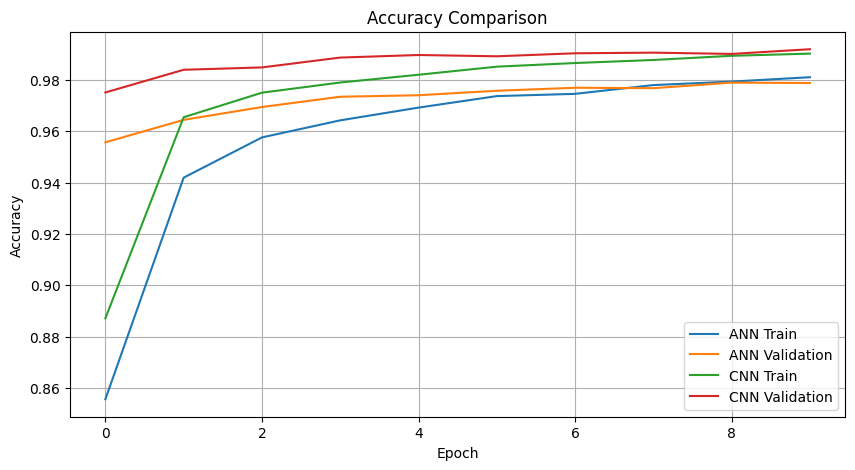

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_ann.history['accuracy'],label='ANN Train')
plt.plot(history_ann.history['val_accuracy'],label='ANN Validation')

plt.plot(history_cnn.history['accuracy'],label='CNN Train')
plt.plot(history_cnn.history['val_accuracy'],label='CNN Validation')

plt.title("Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid()

plt.show()

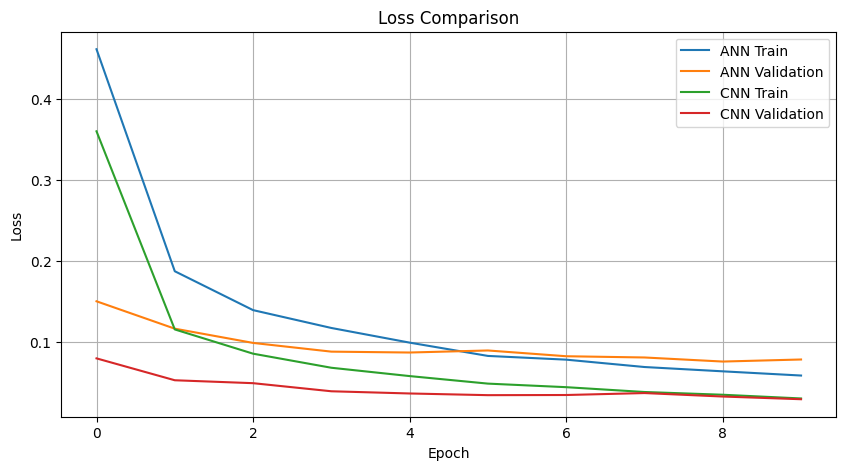

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_ann.history['loss'],label='ANN Train')
plt.plot(history_ann.history['val_loss'],label='ANN Validation')

plt.plot(history_cnn.history['loss'],label='CNN Train')
plt.plot(history_cnn.history['val_loss'],label='CNN Validation')

plt.title("Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()

In [ ]:
print("="*60)
print("{:<15}{:<15}{:<15}".format("Model","Accuracy","Training Time"))
print("="*60)

print("{:<15}{:<15.2f}{:<15.2f}".format("ANN",ann_acc*100,ann_time))
print("{:<15}{:<15.2f}{:<15.2f}".format("CNN",cnn_acc*100,cnn_time))

Model          Accuracy       Training Time  
ANN            97.94          22.83          
CNN            99.30          270.90         
